In [12]:
# 1. CARGA DE DATOS
# ==============================

import pandas as pd

# Cargo el dataset desde la URL
total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/linear-regression-project-tutorial/main/medical_insurance_cost.csv")

# Mostramos las primeras filas para entender la estructura
total_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
# 2. LIMPIEZA DE DATOS


# Eliminamos filas duplicadas (si las hay)
# reset_index sirve para reorganizar el índice después de eliminar filas
total_data = total_data.drop_duplicates().reset_index(drop=True)

total_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [16]:
#TRANSFORMACIÓN + ESCALADO
# ==============================

# Importamos el escalador MinMax
from sklearn.preprocessing import MinMaxScaler

# Convertimos variables categóricas a numéricas
# factorize asigna un número a cada categoría
total_data["sex_n"] = pd.factorize(total_data["sex"])[0]
total_data["smoker_n"] = pd.factorize(total_data["smoker"])[0]
total_data["region_n"] = pd.factorize(total_data["region"])[0]


In [17]:
# Seleccionamos las variables que vamos a usar
num_variables = ["age", "bmi", "children", "sex_n", "smoker_n", "region_n"]


In [18]:
# Creamos el escalador
scaler = MinMaxScaler()

In [20]:
# Aplicamos el escalado (valores entre 0 y 1)
scal_features = scaler.fit_transform(total_data[num_variables])

In [21]:
# Convertimos el resultado a DataFrame
total_data_scal = pd.DataFrame(scal_features, index=total_data.index, columns=num_variables)


In [22]:
# Añadimos la variable objetivo (charges) sin escalar
total_data_scal["charges"] = total_data["charges"]

total_data_scal.head()


,age,bmi,children,sex_n,smoker_n,region_n,charges
0,0.021739,0.321227,0.0,0.0,0.0,0.000000,16884.92400
1,0.000000,0.479150,0.2,1.0,1.0,0.333333,1725.55230
2,0.217391,0.458434,0.6,1.0,1.0,0.333333,4449.46200
3,0.326087,0.181464,0.0,1.0,1.0,0.666667,21984.47061
4,0.304348,0.347592,0.0,1.0,1.0,0.666667,3866.85520


In [23]:

# 4. SELECCIÓN DE VARIABLES (Feature Selection)

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split

In [24]:
# Separamos variables predictoras (X) y objetivo (y)
X = total_data_scal.drop("charges", axis=1)
y = total_data_scal["charges"]

In [25]:
# Dividimos en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Seleccionamos las 4 mejores variables según su relación con el target
selection_model = SelectKBest(f_regression, k=4)

In [27]:
# Entrenamos el selector con los datos de entrenamiento
selection_model.fit(X_train, y_train)

# Obtenemos los nombres de las variables seleccionadas
selected_columns = X_train.columns[selection_model.get_support()]

# Aplicamos la selección a los datos
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns=selected_columns)
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns=selected_columns)

X_train_sel.head()
X_test_sel.head()

,age,bmi,children,smoker_n
0,0.673913,0.176352,0.0,1.0
1,0.239130,0.259349,0.8,1.0
2,0.717391,0.549502,0.6,1.0
3,0.282609,0.495830,0.6,0.0
4,0.282609,0.603444,0.4,1.0


In [30]:

# 5. GUARDAR DATOS PROCESADOS

import os

os.makedirs("../data/processed", exist_ok=True)


# Añadimos la variable objetivo de nuevo
X_train_sel["charges"] = y_train.values
X_test_sel["charges"] = y_test.values

# Guardamos los datasets en archivos CSV
X_train_sel.to_csv("../data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index=False)

In [31]:

#  6. CARGAR DATOS PROCESADOS


train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

train_data.head()

,age,bmi,children,smoker_n,charges
0,0.108696,0.230024,0.0,1.0,2396.09590
1,0.065217,0.263250,0.4,1.0,3279.86855
2,0.739130,0.580172,0.4,1.0,33471.97189
3,0.978261,0.686306,0.0,1.0,13405.39030
4,0.630435,0.286252,0.4,1.0,9715.84100


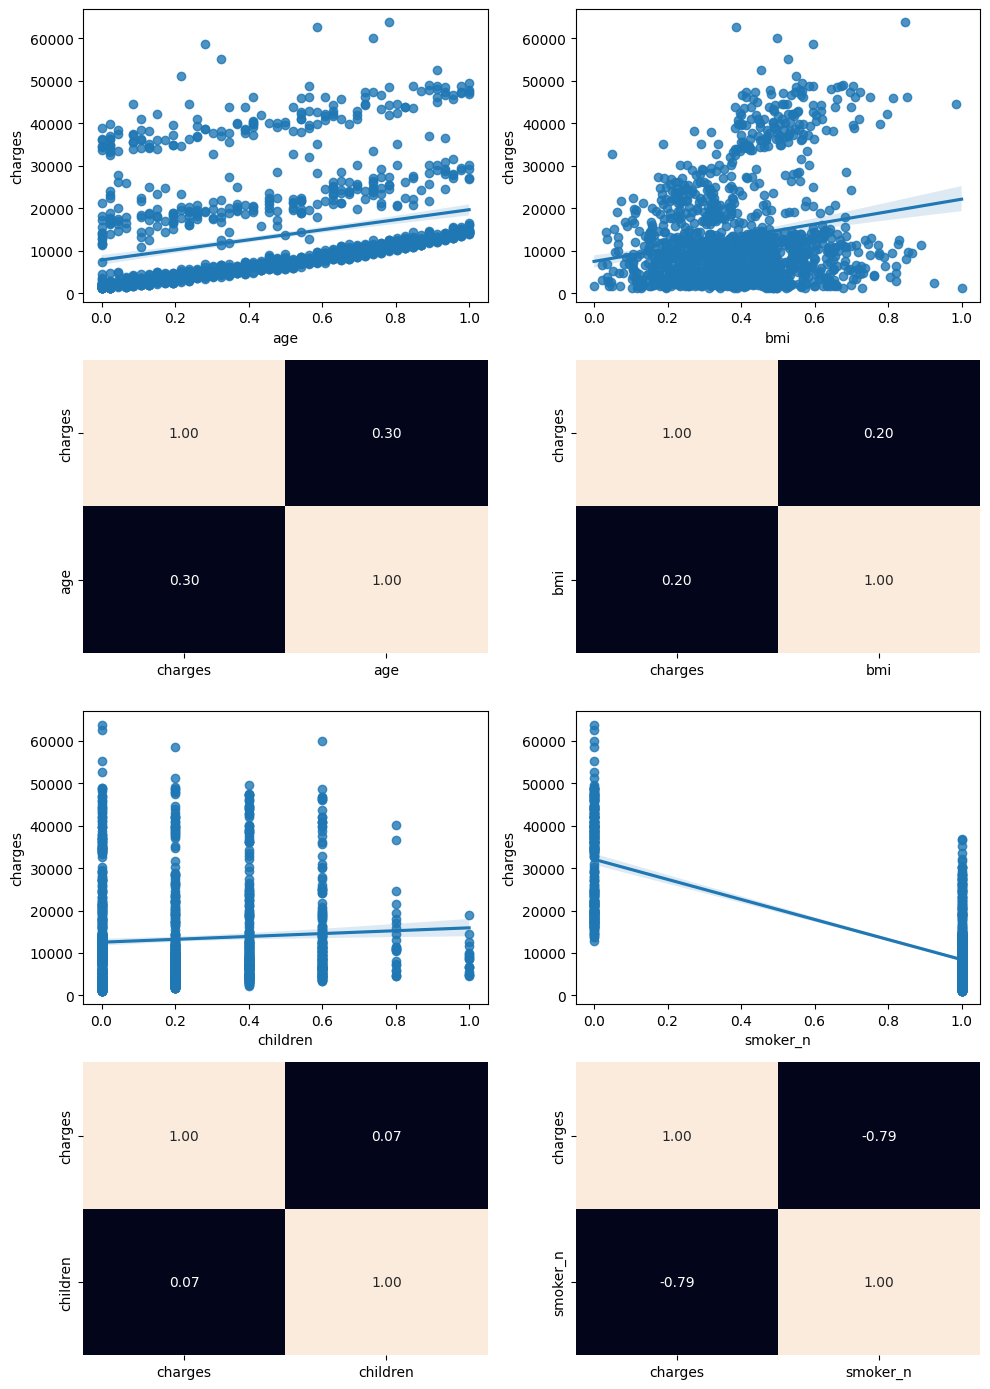

In [33]:

 #7. EDA (ANÁLISIS EXPLORATORIO)


import matplotlib.pyplot as plt
import seaborn as sns

# Unimos train y test para analizar todo el dataset
total_data = pd.concat([train_data, test_data])

# Creamos una figura con varios gráficos
fig, axis = plt.subplots(4, 2, figsize=(10, 14))

# Relación edad vs coste
sns.regplot(data=total_data, x="age", y="charges", ax=axis[0, 0])
sns.heatmap(total_data[["charges", "age"]].corr(), annot=True, fmt=".2f", ax=axis[1, 0], cbar=False)

# Relación BMI vs coste
sns.regplot(data=total_data, x="bmi", y="charges", ax=axis[0, 1])
sns.heatmap(total_data[["charges", "bmi"]].corr(), annot=True, fmt=".2f", ax=axis[1, 1], cbar=False)

# Relación hijos vs coste
sns.regplot(data=total_data, x="children", y="charges", ax=axis[2, 0])
sns.heatmap(total_data[["charges", "children"]].corr(), annot=True, fmt=".2f", ax=axis[3, 0], cbar=False)

# Relación fumador vs coste
sns.regplot(data=total_data, x="smoker_n", y="charges", ax=axis[2, 1])
sns.heatmap(total_data[["charges", "smoker_n"]].corr(), annot=True, fmt=".2f", ax=axis[3, 1], cbar=False)

plt.tight_layout()
plt.show()


In [34]:

#  8. SEPARAR TRAIN Y TEST


X_train = train_data.drop(["charges"], axis=1)
y_train = train_data["charges"]

X_test = test_data.drop(["charges"], axis=1)
y_test = test_data["charges"]

In [35]:

#  9. MODELO DE REGRESIÓN LINEAL


from sklearn.linear_model import LinearRegression

# Creamos el modelo
model = LinearRegression()

# Entrenamos el modelo
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
#  10. COEFICIENTES DEL MODELO

# Intercepto (valor base)
print(f"Intercept (a): {model.intercept_}")

# Coeficientes (importancia de cada variable)
print(f"Coefficients: {model.coef_}")

Intercept (a): 21143.269121973935
Coefficients: [ 11462.79943201  11346.78939471   2689.8609795  -23042.50723793]


In [37]:

#  11. PREDICCIONES


# Predecimos sobre el conjunto de test
y_pred = model.predict(X_test)

y_pred


array([ 7826.71976716,  5936.53265111, 14173.07782788, 31622.75075546,
        9263.34093635, 13480.14887712, 29787.25790395,  1643.45719872,
       10876.17888434, 11325.66257258, 10382.00922092, 33095.82145191,
       30563.99442887, 17375.68543919, 10170.05222026,  9793.97788271,
        4338.87322262, 32040.02942064,  3533.00631632,  5540.63300408,
        3800.90102672, 29849.73579925, 15058.38135413, 30681.25821127,
       30855.22159196,  5318.35517484, 35651.38184556, 36750.00646392,
       10887.72705446, 13731.47292098,  5951.31281261, 13057.0503156 ,
         885.50217102, 12378.3628904 , 39714.81547966, 12430.12415904,
        4898.39413804,  3922.99091642, 31372.98531615,  9306.77316642,
        6376.62829275, 29696.01315781, 35095.36875728, 11850.11609205,
        7372.07939253,  3596.50605624,  5524.8651415 ,  9123.94398722,
        4175.68935164,  9410.0034801 ,  6870.37575452, 11482.89235724,
       30753.06314612,  3901.63926993, 11213.80257282, 10152.26872403,
      

In [38]:

#  12. EVALUACIÓN DEL MODELO


from sklearn.metrics import mean_squared_error, r2_score

# Error cuadrático medio
print(f"MSE: {mean_squared_error(y_test, y_pred)}")

# Coeficiente de determinación (qué tan bien predice el modelo)
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 35914551.48043365
R2 Score: 0.8045531086669286


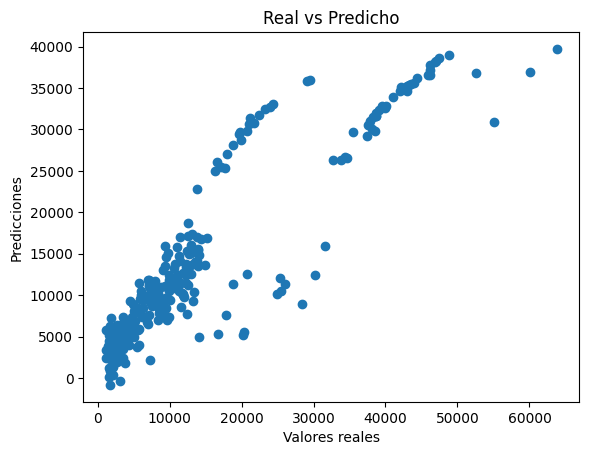

In [39]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho")
plt.show()

he hecho un testeo arriba para ver como funciona y esta es mi conclusion:

El gráfico de valores reales vs predichos muestra que el modelo captura la tendencia general de los datos, ya que existe una relación positiva entre ambos.

Sin embargo, se observa cierta dispersión en los puntos, lo que indica que el modelo comete errores en algunas predicciones.

Esto sugiere que, aunque el modelo es razonablemente bueno, podría mejorarse incorporando más variables o utilizando modelos más complejos.